make mesh

In [16]:
import gmsh


def make_mesh(
    radius: float = 1.0,
    mesh_size: float = 0.06,
    element_order: int = 1,
):
    gmsh.initialize()
    gmsh.model.add("disk")

    model = gmsh.model
    occ = model.occ

    # Disk centred at the origin
    disk = occ.addDisk(
        0.0,
        0.0,
        0.0,
        radius,
        radius,
    )

    occ.synchronize()

    # Physical tag for the two-dimensional domain
    DOMAIN_TAG = 1
    model.addPhysicalGroup(2, [disk], DOMAIN_TAG)
    model.setPhysicalName(2, DOMAIN_TAG, "Domain")

    # Physical tag for the circular boundary
    boundary = model.getBoundary(
        [(2, disk)],
        oriented=False,
        recursive=False,
    )
    boundary_curves = [tag for dim, tag in boundary if dim == 1]

    BOUNDARY_TAG = 1
    model.addPhysicalGroup(1, boundary_curves, BOUNDARY_TAG)
    model.setPhysicalName(1, BOUNDARY_TAG, "ReflectingBoundary")

    # Uniform mesh size
    model.mesh.setSize(model.getEntities(0), mesh_size)

    gmsh.option.setNumber("Mesh.Algorithm", 6)
    gmsh.option.setNumber("Mesh.MshFileVersion", 4.1)
    gmsh.option.setNumber("Mesh.ElementOrder", element_order)  

    model.mesh.generate(2)
    gmsh.option.setNumber("Mesh.HighOrderOptimize", 2)
    model.mesh.optimize("HighOrder")

    gmsh.write("disk.msh")
    gmsh.finalize()

make_mesh()

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.000244878s, CPU 0.000243s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.065483s, CPU 0.066132s)
Info    : 1095 nodes 2189 elements
Info    : Optimizing mesh (HighOrder)...
Info    : Optimizing high-order mesh...
Info    : Optimizing mesh...
Info    : Computing connectivity and bad elements for entity 1...
Info    : Starting patch generation from 0 bad elements...
Info    : Constructing 0 primary patches
Info    : Computing patch connectivity...
Info    : Identifying groups of primary patches...
Info    : Merging primary patches into 0 patches...
Info    : Computing boundaries for 0 patches...
Info    : Generated 0 patches
Info    : Optimization succeeded
Info    : Done optimizing mesh (0.004538 s)
Info    : Done optimizing high-order mesh (0.004538 s)
Info    : Done optimizing mesh (Wall 0.00407847s, CPU 0.005261s)
Info    : Wr

helper functions

In [17]:
import numpy as np
from firedrake import *
import dean_kawasaki_DG as dkDG


def _normalised_initial_condition(V):
    rho = Function(V, name="rho")
    rho.interpolate(Constant(1.0))
    rho.assign(rho / assemble(rho * dx))
    return rho


def _positive_part(source, target):
    target.dat.data[:] = np.maximum(source.dat.data_ro, 0.0)


def _outward_drift(mesh, potential_strength):
    x = SpatialCoordinate(mesh)
    return potential_strength * as_vector(x)

def _sipdg_neumann_diffusion_form(mesh, u, v, eta):
    n = FacetNormal(mesh)
    h = CellDiameter(mesh)

    return (
        inner(grad(u), grad(v)) * dx
        - inner(avg(grad(u)), jump(v, n)) * dS
        - inner(avg(grad(v)), jump(u, n)) * dS
        + eta / avg(h) * inner(jump(u, n), jump(v, n)) * dS
    )

def _advection_form(
    mesh,
    u,
    v,
    potential_strength,
    flux="upwind",
):
    b = _outward_drift(mesh, potential_strength)

    volume = -inner(u * b, grad(v)) * dx

    if flux == "central":
        return (
            volume
            + inner(avg(u * b), jump(v, FacetNormal(mesh))) * dS
        )

    if flux != "upwind":
        raise ValueError(
            f"Unknown flux '{flux}'. Expected 'upwind' or 'central'."
        )

    n = FacetNormal(mesh)

    # Normal velocity with respect to the '+' element normal
    normal_velocity = dot(avg(b), n("+"))

    upwind_value = conditional(
        normal_velocity >= 0.0,
        u("+"),
        u("-"),
    )

    interior_flux = (
        normal_velocity
        * upwind_value
        * jump(v)
        * dS
    )

    return volume + interior_flux

solve function

In [18]:
def _solve_dg(
    mesh_file,
    degree,
    dt,
    final_time,
    diffusion,
    potential_strength,
    num_particles,
    seed,
    noise_gradient,
    flux="upwind",
    stochastic=True,
):
    mesh = Mesh(mesh_file)

    V = FunctionSpace(mesh, "DG", degree)

    rho_old = _normalised_initial_condition(V)
    rho_positive = Function(V, name=f"dg_{flux}_positive")

    rho = TrialFunction(V)
    v = TestFunction(V)

    eta = 20.0

    noise = None
    if stochastic:
        noise = dkDG.DeanKawasakiNoise(
            mesh,
            V,
            degree,
            dt,
            diffusion,
            num_particles,
            "equispaced",
            gradient=noise_gradient,
            include_jump_terms=True,
            seed=seed,
        )

    diffusion_form = _sipdg_neumann_diffusion_form(
        mesh,
        rho,
        v,
        eta,
    )

    advection_form = _advection_form(
        mesh,
        rho,
        v,
        potential_strength,
        flux=flux,
    )

    a = (
        inner(rho, v) * dx
        + dt * diffusion * diffusion_form
        + dt * advection_form
    )

    L = inner(rho_old, v) * dx

    if noise is not None:
        L += noise.variational_form(v)

    rho_new = Function(V, name=f"dg_{flux}")

    problem = LinearVariationalProblem(a, L, rho_new)

    solver = LinearVariationalSolver(
        problem,
        solver_parameters={
            "mat_type": "aij",
            "ksp_type": "preonly",
            "pc_type": "lu",
        },
    )

    num_steps = int(round(final_time / dt))

    for _ in range(num_steps):
        if noise is not None:
            _positive_part(rho_old, rho_positive)
            noise.sample(rho_positive)

        solver.solve()
        rho_old.assign(rho_new)

    return rho_old

run function

In [19]:
def run(degree=1):
    params = {
        "mesh_file": "disk.msh",
        "degree": int(degree),
        "dt": 1.0e-3,
        "final_time": 5.0,
        "diffusion": 0.125/2,
        "potential_strength": 0.25,
        "num_particles": 1e5,
        "seed": 123,
        "noise_gradient": "full",
    }
    return _solve_dg(flux="upwind", **params)

exact particle equilibrium (found by solving steady state Fokker-Planck in cylindrical coordinates)

In [20]:
def exact_equilibrium(
    V,
    diffusion,
    potential_strength,
    radius=1.0,
):
    mesh = V.mesh()
    x = SpatialCoordinate(mesh)
    r_squared = dot(as_vector(x), as_vector(x))

    exponent_at_boundary = (
        potential_strength
        * radius**2
        / (2.0 * diffusion)
    )

    normalisation = (
        potential_strength
        /
        (
            2.0
            * np.pi
            * diffusion
            * np.expm1(exponent_at_boundary)
        )
    )

    rho_equilibrium = Function(V, name="exact_equilibrium")

    rho_equilibrium.interpolate(
        normalisation
        * exp(
            potential_strength
            * r_squared
            / (2.0 * diffusion)
        )
    )

    return rho_equilibrium

helper function to sample particles from exact equilibrium density

In [21]:
import numpy as np


def sample_particle_equilibrium(
    num_particles: int,
    radius: float,
    diffusion: float,
    potential_strength: float,
    seed: int | None = None,
) -> np.ndarray:
    """
    Sample independent particles from the exact equilibrium density

        rho_inf(x) ∝ exp(alpha * |x|^2 / (2D))

    on the disk |x| <= radius.
    """
    if num_particles <= 0:
        raise ValueError("num_particles must be positive.")

    if radius <= 0.0:
        raise ValueError("radius must be positive.")

    if diffusion <= 0.0:
        raise ValueError("diffusion must be positive.")

    if potential_strength < 0.0:
        raise ValueError(
            "This sampler assumes an outward potential_strength >= 0."
        )

    rng = np.random.default_rng(seed)

    u = rng.random(num_particles)
    theta = 2.0 * np.pi * rng.random(num_particles)

    chi = (
        potential_strength
        * radius**2
        / (2.0 * diffusion)
    )

    if abs(chi) < 1.0e-10:
        # Uniform distribution on the disk
        radial = radius * np.sqrt(u)
    else:
        radial = radius * np.sqrt(
            np.log1p(u * np.expm1(chi)) / chi
        )

    particles = np.column_stack(
        (
            radial * np.cos(theta),
            radial * np.sin(theta),
        )
    )

    return particles

run dG method

In [22]:
stochastic = run()

sample particles

In [23]:
particles = sample_particle_equilibrium(
    num_particles=int(1e5),
    radius=1.0,
    diffusion=0.125/2,
    potential_strength=0.25,
    seed=123,
)

helper to convert particle positions to a density over the disk

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from matplotlib.colors import Normalize
from matplotlib.patches import Circle
from firedrake.pyplot import tripcolor


def particle_density_grid(
    particles,
    radius=1.0,
    bins=200,
    smoothing_sigma=1.0,
):
    """
    Convert particle positions into an area-normalized density on a
    Cartesian grid covering the disk.

    The returned density integrates approximately to one over the disk.
    """
    x_edges = np.linspace(-radius, radius, bins + 1)
    y_edges = np.linspace(-radius, radius, bins + 1)

    counts, _, _ = np.histogram2d(
        particles[:, 0],
        particles[:, 1],
        bins=[x_edges, y_edges],
    )

    dx = x_edges[1] - x_edges[0]
    dy = y_edges[1] - y_edges[0]

    # histogram2d indexes as [x, y], while plotting routines expect [y, x]
    density = counts.T / (len(particles) * dx * dy)

    if smoothing_sigma is not None and smoothing_sigma > 0.0:
        density = gaussian_filter(
            density,
            sigma=smoothing_sigma,
            mode="constant",
        )

    x_centres = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centres = 0.5 * (y_edges[:-1] + y_edges[1:])

    X, Y = np.meshgrid(x_centres, y_centres)
    inside_disk = X**2 + Y**2 <= radius**2

    # Hide the Cartesian grid outside the physical domain.
    density[~inside_disk] = np.nan

    # Smoothing can move a small amount of mass outside the disk.
    # Renormalize the displayed density over the disk.
    numerical_mass = np.nansum(density) * dx * dy

    if numerical_mass > 0.0:
        density /= numerical_mass

    return x_edges, y_edges, density

In [25]:
x_edges, y_edges, particle_density = particle_density_grid(
    particles,
    radius=1.0,
    bins=150,
    smoothing_sigma=1.0,
)

plot dG solution next to particles

In [26]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "mathtext.fontset": "cm",
        "text.latex.preamble": r"\usepackage{amsmath,amssymb}",
    }
)

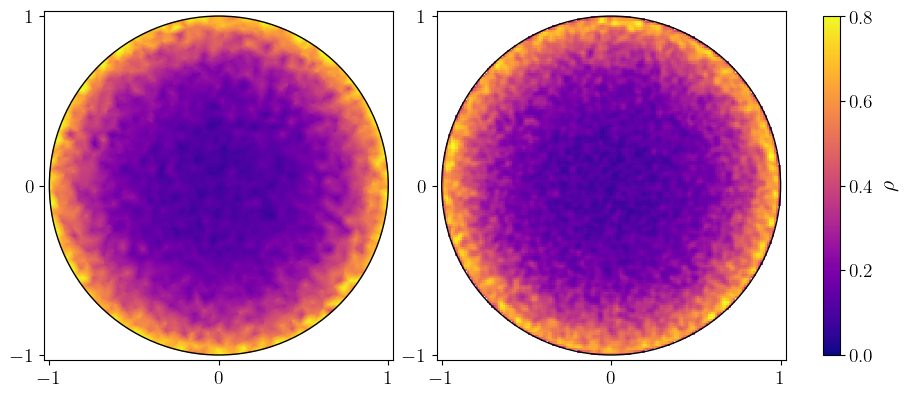

In [27]:
rho_dk = stochastic
dk_values = rho_dk.dat.data_ro

vmin = 0.0
vmax = max(
    np.nanpercentile(particle_density, 99.5),
    np.percentile(dk_values, 99.5),
)

norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    constrained_layout=True,
)

cmap="plasma"

# Dean--Kawasaki realization
dk_plot = tripcolor(
    rho_dk,
    axes=axes[0],
    norm=norm,
    cmap=cmap,
)


# Particle density
particle_plot = axes[1].pcolormesh(
    x_edges,
    y_edges,
    particle_density,
    shading="auto",
    norm=norm,
    cmap=cmap,
    linewidth=0,
    edgecolors="none",
    antialiased=False,
    rasterized=True,
)

for ax in axes:
    ax.add_patch(
        Circle(
            (0.0, 0.0),
            1.0,
            fill=False,
            edgecolor="black",
            linewidth=1.0,
        )
    )
    ax.set_aspect("equal")
    ax.set_xlim(-1.03, 1.03)
    ax.set_ylim(-1.03, 1.03)
    ax.set_xticks([-1.0, 0.0, 1.0])
    ax.set_yticks([-1.0, 0.0, 1.0])

cbar = fig.colorbar(
    dk_plot,
    ax=axes,
    label=r"$\rho$",
    shrink=0.9,
)

cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8])
cbar.set_ticklabels([r"$0.0$", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$"])

title_size = 18
tick_size = 14
label_size = 16

for ax in axes:
    ax.tick_params(
        axis="both",
        labelsize=tick_size,
    )

    ax.xaxis.label.set_size(label_size)
    ax.yaxis.label.set_size(label_size)
    ax.title.set_size(title_size)

cbar.ax.tick_params(labelsize=tick_size)
cbar.ax.yaxis.label.set_size(label_size)

# plt.savefig(
#     "dk_particle_equilibrium_comparison.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()